# Lab 6
## Abdulaziz Saqer BinRuqush - 2230007229

### Environment Setup
This cell installs any missing packages. It is safe in both local Jupyter and Google Colab.


In [1]:
import importlib
import subprocess
import sys
from pathlib import Path

local_site = Path('.pydeps')
local_site.mkdir(exist_ok=True)
local_site_str = str(local_site.resolve())
if local_site_str not in sys.path:
    # Keep base environment first to avoid ABI mismatch for preinstalled compiled packages.
    sys.path.append(local_site_str)


def ensure_module(module_name, install_specs):
    try:
        module = importlib.import_module(module_name)
        print(f'{module_name} already available.')
        return module
    except Exception as exc:
        print(f'Installing {module_name} ({exc.__class__.__name__}).')

    cmd = [
        sys.executable,
        '-m',
        'pip',
        'install',
        '--upgrade',
        '--target',
        local_site_str,
        *install_specs,
    ]
    subprocess.check_call(cmd)
    importlib.invalidate_caches()
    return importlib.import_module(module_name)


# Ensure core scientific stack from base env
importlib.import_module('numpy')
importlib.import_module('matplotlib')
importlib.import_module('PIL')

# Install only packages missing from base env into local folder with NumPy<2 compatibility.
ensure_module('cv2', ['opencv-python-headless==4.10.0.84', 'numpy<2'])
ensure_module('skimage', ['scikit-image==0.22.0', 'numpy<2'])

print('Dependency check complete.')


cv2 already available.
skimage already available.
Dependency check complete.


### Path and Utility Helpers
These helpers make the notebook run on both local Jupyter and Google Colab.


In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data, exposure


def is_colab():
    return Path('/content').exists()


def find_images_dir():
    candidates = []
    if is_colab():
        candidates.extend([
            Path('/content/Images'),
            Path('/content/Labs/Images')
        ])
    cwd = Path.cwd()
    candidates.extend([
        cwd / 'Images',
        cwd.parent / 'Images'
    ])
    for p in candidates:
        if p.exists():
            return p
    return None


IMAGES_DIR = find_images_dir()
OUTPUT_DIR = Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f'Colab runtime: {is_colab()}')
print(f'Images dir: {IMAGES_DIR}')
print(f'Output dir: {OUTPUT_DIR.resolve()}')


def show_images(images, titles, cmap=None, figsize=(15, 5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        plt.subplot(1, len(images), i)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap if cmap else 'gray')
        else:
            plt.imshow(img)
        plt.title(title)
        plt.axis('off')
    plt.tight_layout()
    plt.show()


def to_rgb(image_bgr):
    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def load_color_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['Parrot.png', 'parrot.png', 'input.jpg', 'input.png', 'lena_grayscale_image.jpg']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_COLOR)
                if img is not None:
                    print(f'Loaded local image: {p}')
                    return img
    print('Using skimage.data.astronaut() as fallback color image.')
    astro_rgb = data.astronaut()
    return cv2.cvtColor(astro_rgb, cv2.COLOR_RGB2BGR)


def load_gray_image_fallback():
    if IMAGES_DIR is not None:
        for name in ['cameraman.jpg', 'lena_grayscale_image.jpg', 'input.jpg', 'input.png']:
            p = IMAGES_DIR / name
            if p.exists():
                img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    print(f'Loaded local grayscale image: {p}')
                    return img
    print('Using skimage.data.camera() as fallback grayscale image.')
    cam = data.camera()
    return cam.astype(np.uint8)


Colab runtime: False
Images dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\Images
Output dir: C:\Users\aziz\OneDrive\Desktop\Level 8\Image Processing\Labs\outputs


## Procedural Steps

### Task 1: Laplacian Filtering in the Frequency Domain

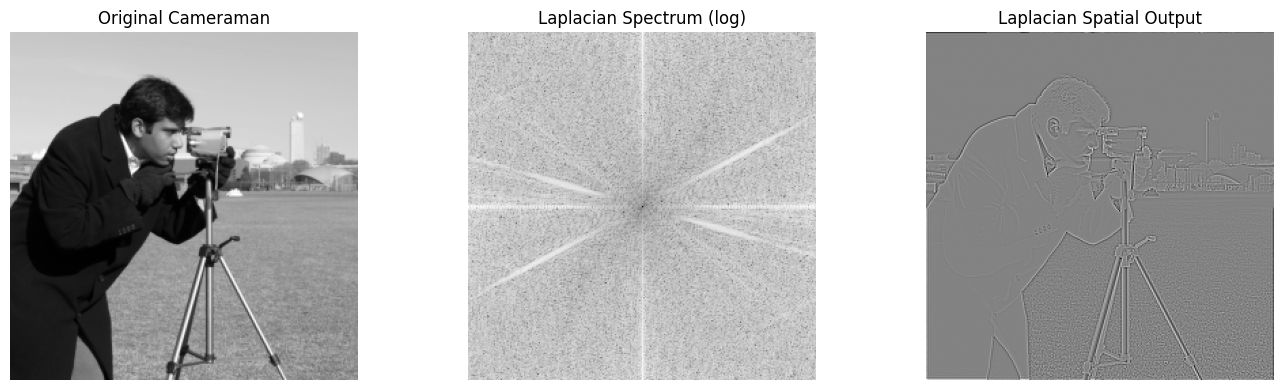

In [3]:
from numpy.fft import fft2, ifft2
from skimage.transform import resize

image = data.camera().astype(np.float32)
image = resize(image, (256, 256), anti_aliasing=True)

M, N = image.shape
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)
laplacian_filter = -4 * (np.pi ** 2) * (u ** 2 + v ** 2)

F = fft2(image)
F_lap = F * laplacian_filter
laplacian_image = ifft2(F_lap).real

plt.figure(figsize=(14, 4))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F_lap))), cmap='gray')
plt.title('Laplacian Spectrum (log)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian Spatial Output')
plt.axis('off')

plt.tight_layout()
plt.show()


## Assessment Tasks

### Task 1: Sobel Filter(s) in the Frequency Domain

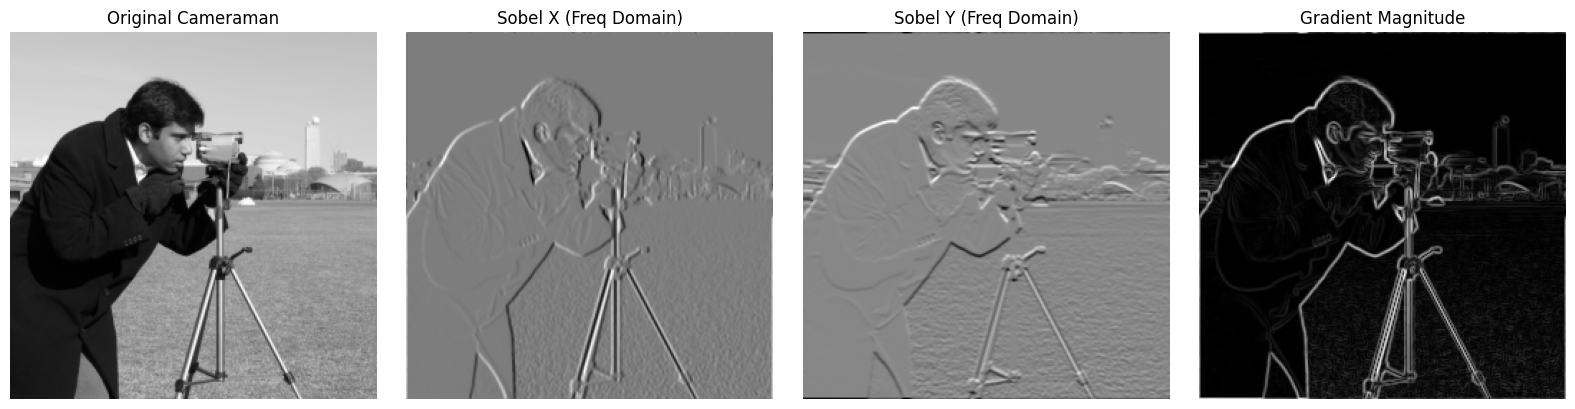

In [4]:
from numpy.fft import fft2, ifft2, ifftshift

sobel_x = np.array([[-1, 0, 1],
                    [-2, 0, 2],
                    [-1, 0, 1]], dtype=np.float32)

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]], dtype=np.float32)


def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape, dtype=np.float32)
    kh, kw = kernel.shape
    ph, pw = shape
    cy, cx = ph // 2, pw // 2
    padded[cy - kh // 2:cy - kh // 2 + kh, cx - kw // 2:cx - kw // 2 + kw] = kernel
    return fft2(ifftshift(padded))

F_img = fft2(image)
H_x = center_embed_kernel(sobel_x, image.shape)
H_y = center_embed_kernel(sobel_y, image.shape)

Gx = ifft2(F_img * H_x).real
Gy = ifft2(F_img * H_y).real
Gmag = np.sqrt(Gx ** 2 + Gy ** 2)

plt.figure(figsize=(16, 4))
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(Gx, cmap='gray')
plt.title('Sobel X (Freq Domain)')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(Gy, cmap='gray')
plt.title('Sobel Y (Freq Domain)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(Gmag, cmap='gray')
plt.title('Gradient Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()
